# PowerFactory Simulation - Advanced Usage

This notebook covers advanced topics:
1. Multiple grid comparisons
2. Parameter sensitivity analysis
3. Batch simulations with different configurations
4. Configuration files (YAML)
5. Custom analysis and visualization
6. Switching between mock and PowerFactory engines

In [1]:
from tranpy.simulation import (
    PowerSystemSimulator,
    generate_dataset_from_simulation,
    SimulationConfig,
    load_config_from_yaml,
    save_config_to_yaml,
    create_config_from_template
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
%matplotlib inline

/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/dalex/_global_checks.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Compare Multiple Grids

Generate datasets for both IEEE 9-bus and New England 39-bus systems:

In [2]:
# Configuration
SIMULATION_ENGINE = 'mock'  # Change to 'powerfactory' for real simulation
NUM_EVENTS = 100

grids = ['NineBusSystem', 'NewEngland']
all_results = {}

for grid in grids:
    print(f"\nSimulating {grid}...")
    
    simulator = PowerSystemSimulator(
        grid=grid,
        simulation_time=10.0,
        output_dir=f'advanced_results/{grid}',
        simulation_engine=SIMULATION_ENGINE
    )
    
    results = simulator.run(
        num_events=NUM_EVENTS,
        fault_clearing_time=[10, 12],
        max_load_change=[60, 60],
        random_seed=42
    )
    
    all_results[grid] = results
    print(f"✓ {grid}: {results}")


Simulating NineBusSystem...

Mock Simulation: NineBusSystem
Generating 100 synthetic events...
Fault clearing: 10 cycles, Max load: 60%

Event 10/100... ✓
Event 20/100... ✓
Event 30/100... ✓
Event 40/100... ✓
Event 50/100... ✓
Event 60/100... ✓
Event 70/100... ✓
Event 80/100... ✓
Event 90/100... ✓
Event 100/100... ✓

Mock Simulation Complete:
  Total events: 100
  Stable: 70 (70.0%)
  Unstable: 30

✓ Saved results: advanced_results/NineBusSystem/NineBusSystem/pickles/NineBusSystem_results.pickle
✓ Saved legacy format: advanced_results/NineBusSystem/data/NineBusSystem.pickle
✓ NineBusSystem: SimulationResults(grid='NineBusSystem', n_events=100, stable=70, unstable=30)

Simulating NewEngland...

Mock Simulation: NewEngland
Generating 100 synthetic events...
Fault clearing: 12 cycles, Max load: 60%

Event 10/100... ✓
Event 20/100... ✓
Event 30/100... ✓
Event 40/100... ✓
Event 50/100... ✓
Event 60/100... ✓
Event 70/100... ✓
Event 80/100... ✓
Event 90/100... ✓
Event 100/100... ✓

Mock Simu

### Compare Grid Statistics

,Grid,Total Events,Stable,Unstable,Stability %
0,NineBusSystem,100,70,30,70.0%
1,NewEngland,100,56,44,56.0%


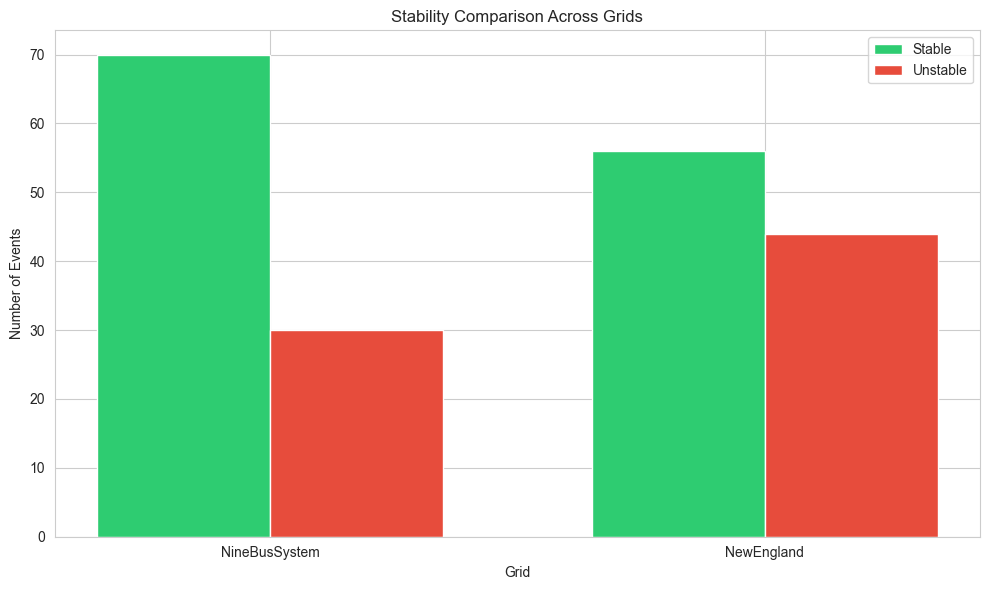

In [3]:
# Comparison DataFrame
comparison_data = []
for grid, results in all_results.items():
    stats = results.get_statistics()
    comparison_data.append({
        'Grid': grid,
        'Total Events': stats['total_events'],
        'Stable': stats['stable_events'],
        'Unstable': stats['unstable_events'],
        'Stability %': f"{stats['stability_ratio']*100:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(grids))
width = 0.35

stable_counts = [all_results[g].get_statistics()['stable_events'] for g in grids]
unstable_counts = [all_results[g].get_statistics()['unstable_events'] for g in grids]

ax.bar(x - width/2, stable_counts, width, label='Stable', color='#2ecc71')
ax.bar(x + width/2, unstable_counts, width, label='Unstable', color='#e74c3c')

ax.set_xlabel('Grid')
ax.set_ylabel('Number of Events')
ax.set_title('Stability Comparison Across Grids')
ax.set_xticks(x)
ax.set_xticklabels(grids)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Parameter Sensitivity Analysis

Study how fault clearing time affects stability:

In [4]:
# Test different clearing times
clearing_times = [8, 10, 12, 14, 16]
sensitivity_results = []

for clearing_cycles in clearing_times:
    print(f"\nTesting clearing time: {clearing_cycles} cycles")
    
    simulator = PowerSystemSimulator(
        grid='NewEngland',
        simulation_engine='mock',
        output_dir=f'sensitivity/clearing_{clearing_cycles}'
    )
    
    results = simulator.run(
        num_events=50,
        fault_clearing_time=[10, clearing_cycles],
        max_load_change=[60, 60],
        random_seed=42
    )
    
    stats = results.get_statistics()
    sensitivity_results.append({
        'Clearing Time (cycles)': clearing_cycles,
        'Clearing Time (ms)': clearing_cycles * 20,  # 50 Hz system
        'Stability Ratio': stats['stability_ratio'],
        'Stable Events': stats['stable_events'],
        'Unstable Events': stats['unstable_events']
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)


Testing clearing time: 8 cycles

Mock Simulation: NewEngland
Generating 50 synthetic events...
Fault clearing: 8 cycles, Max load: 60%

Event 10/50... ✓
Event 20/50... ✓
Event 30/50... ✓
Event 40/50... ✓
Event 50/50... ✓

Mock Simulation Complete:
  Total events: 50
  Stable: 41 (82.0%)
  Unstable: 9

✓ Saved results: sensitivity/clearing_8/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: sensitivity/clearing_8/data/NewEngland.pickle

Testing clearing time: 10 cycles

Mock Simulation: NewEngland
Generating 50 synthetic events...
Fault clearing: 10 cycles, Max load: 60%

Event 10/50... ✓
Event 20/50... ✓
Event 30/50... ✓
Event 40/50... ✓
Event 50/50... ✓

Mock Simulation Complete:
  Total events: 50
  Stable: 26 (52.0%)
  Unstable: 24

✓ Saved results: sensitivity/clearing_10/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: sensitivity/clearing_10/data/NewEngland.pickle

Testing clearing time: 12 cycles

Mock Simulation: NewEngland
Generating 50 sy

,Clearing Time (cycles),Clearing Time (ms),Stability Ratio,Stable Events,Unstable Events
0,8,160,0.82,41,9
1,10,200,0.52,26,24
2,12,240,0.52,26,24
3,14,280,0.54,27,23
4,16,320,0.54,27,23


### Visualize Sensitivity

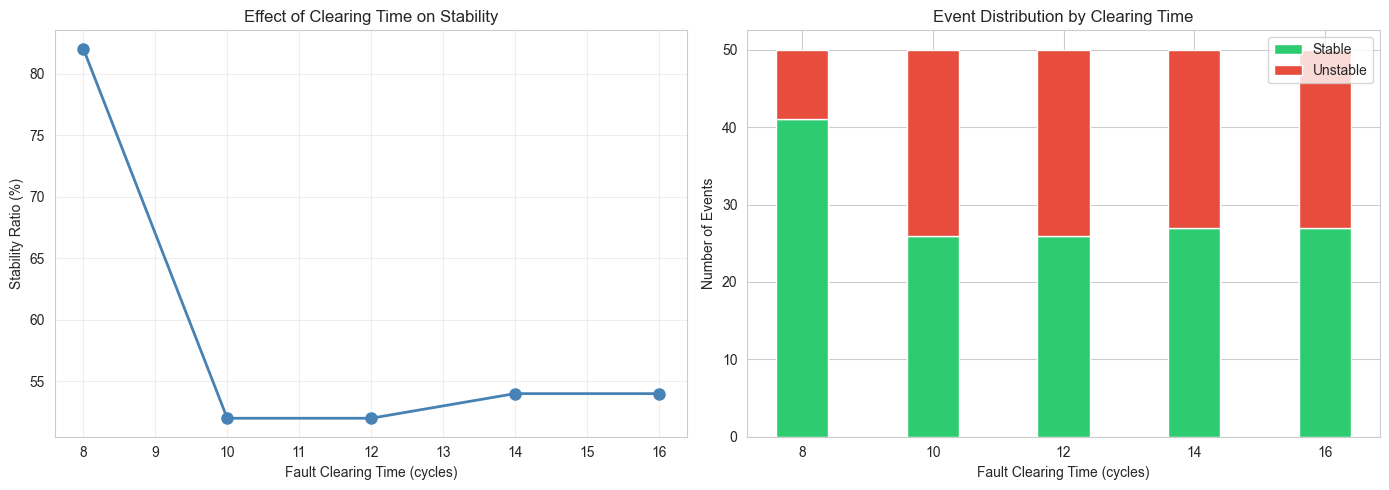

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stability ratio vs clearing time
axes[0].plot(sensitivity_df['Clearing Time (cycles)'], 
             sensitivity_df['Stability Ratio'] * 100, 
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Fault Clearing Time (cycles)')
axes[0].set_ylabel('Stability Ratio (%)')
axes[0].set_title('Effect of Clearing Time on Stability')
axes[0].grid(True, alpha=0.3)

# Stacked bar chart
axes[1].bar(sensitivity_df['Clearing Time (cycles)'], 
            sensitivity_df['Stable Events'], 
            label='Stable', color='#2ecc71')
axes[1].bar(sensitivity_df['Clearing Time (cycles)'], 
            sensitivity_df['Unstable Events'], 
            bottom=sensitivity_df['Stable Events'],
            label='Unstable', color='#e74c3c')
axes[1].set_xlabel('Fault Clearing Time (cycles)')
axes[1].set_ylabel('Number of Events')
axes[1].set_title('Event Distribution by Clearing Time')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Configuration Files

Use YAML configuration for reproducible experiments:

In [6]:
# Create configuration from template
config = create_config_from_template(
    'standard',
    grid='NewEngland',
    simulation_engine='mock',  # Easy to switch!
    number_of_events=200
)

print(config)

# Save configuration
config_path = Path('my_experiment_config.yaml')
save_config_to_yaml(config, config_path)
print(f"\n✓ Configuration saved to: {config_path}")

SimulationConfig(
  grid='NewEngland',
  engine='mock',
  n_events=200,
  clearing_cycles=12,
  max_load=60%
)
✓ Saved configuration: my_experiment_config.yaml

✓ Configuration saved to: my_experiment_config.yaml


### Run from Configuration File

In [7]:
# Load configuration
loaded_config = load_config_from_yaml(config_path)

# Create simulator from config
simulator = PowerSystemSimulator(
    grid=loaded_config.grid,
    simulation_time=loaded_config.simulation_time,
    output_dir=loaded_config.output_path,
    simulation_engine=loaded_config.simulation_engine
)

# Run
results = simulator.run(
    num_events=loaded_config.number_of_events,
    fault_clearing_time=loaded_config.fault_clearing_time_cycles,
    max_load_change=loaded_config.max_load_change,
    random_seed=loaded_config.random_seed
)

print(f"\n{results}")


Mock Simulation: NewEngland
Generating 200 synthetic events...
Fault clearing: 12 cycles, Max load: 60%

Event 10/200... ✓
Event 20/200... ✓
Event 30/200... ✓
Event 40/200... ✓
Event 50/200... ✓
Event 60/200... ✓
Event 70/200... ✓
Event 80/200... ✓
Event 90/200... ✓
Event 100/200... ✓
Event 110/200... ✓
Event 120/200... ✓
Event 130/200... ✓
Event 140/200... ✓
Event 150/200... ✓
Event 160/200... ✓
Event 170/200... ✓
Event 180/200... ✓
Event 190/200... ✓
Event 200/200... ✓

Mock Simulation Complete:
  Total events: 200
  Stable: 129 (64.5%)
  Unstable: 71

✓ Saved results: simulation_results/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: simulation_results/data/NewEngland.pickle

SimulationResults(grid='NewEngland', n_events=200, stable=129, unstable=71)


## 4. Detailed Feature Analysis

Deep dive into generated features:

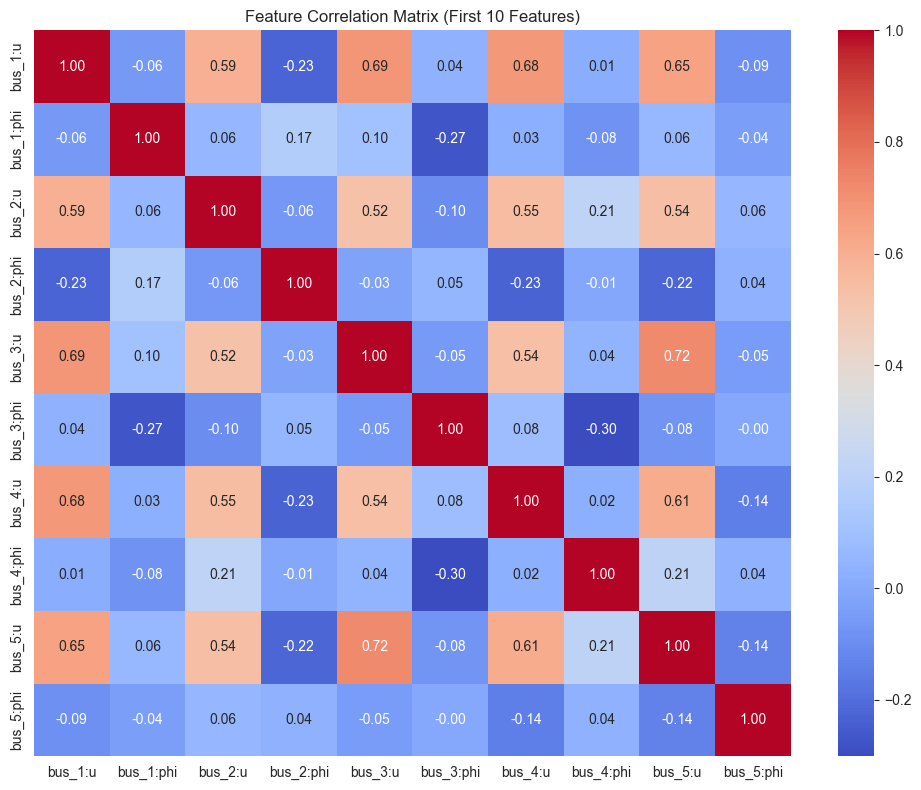

In [8]:
# Generate dataset
dataset, splits = generate_dataset_from_simulation(results)

# Analyze feature correlation
train_df = splits['train']
features_only = train_df.drop('stable-unstable', axis=1)

# Select subset of features for visualization
feature_subset = features_only.iloc[:, :10]  # First 10 features

fig, ax = plt.subplots(figsize=(10, 8))
correlation = feature_subset.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlation Matrix (First 10 Features)')
plt.tight_layout()
plt.show()

### Feature Importance (Simple Analysis)

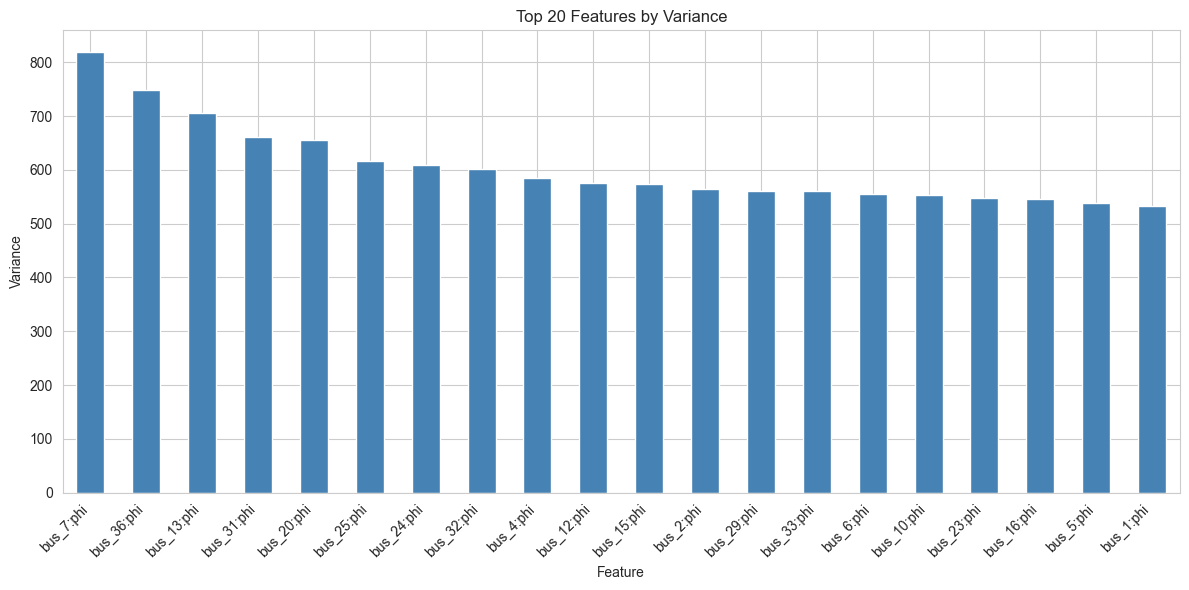

In [9]:
# Calculate feature variance (simple importance metric)
feature_variance = features_only.var().sort_values(ascending=False)

# Plot top 20 features by variance
fig, ax = plt.subplots(figsize=(12, 6))
feature_variance.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 20 Features by Variance')
ax.set_xlabel('Feature')
ax.set_ylabel('Variance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Batch Experiments

Run multiple experiments with different parameters:

In [10]:
# Define experiment matrix
experiments = [
    {'name': 'baseline', 'clearing': 12, 'load': 60},
    {'name': 'fast_clearing', 'clearing': 8, 'load': 60},
    {'name': 'high_load', 'clearing': 12, 'load': 80},
    {'name': 'stressed', 'clearing': 14, 'load': 80}
]

experiment_results = []

for exp in experiments:
    print(f"\nRunning experiment: {exp['name']}")
    
    simulator = PowerSystemSimulator(
        grid='NewEngland',
        simulation_engine='mock',
        output_dir=f"experiments/{exp['name']}"
    )
    
    results = simulator.run(
        num_events=50,
        fault_clearing_time=[10, exp['clearing']],
        max_load_change=[60, exp['load']],
        random_seed=42
    )
    
    stats = results.get_statistics()
    experiment_results.append({
        'Experiment': exp['name'],
        'Clearing (cycles)': exp['clearing'],
        'Max Load (%)': exp['load'],
        'Stability %': f"{stats['stability_ratio']*100:.1f}%",
        'Stable': stats['stable_events'],
        'Unstable': stats['unstable_events']
    })

exp_df = pd.DataFrame(experiment_results)
display(exp_df)


Running experiment: baseline

Mock Simulation: NewEngland
Generating 50 synthetic events...
Fault clearing: 12 cycles, Max load: 60%

Event 10/50... ✓
Event 20/50... ✓
Event 30/50... ✓
Event 40/50... ✓
Event 50/50... ✓

Mock Simulation Complete:
  Total events: 50
  Stable: 26 (52.0%)
  Unstable: 24

✓ Saved results: experiments/baseline/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: experiments/baseline/data/NewEngland.pickle

Running experiment: fast_clearing

Mock Simulation: NewEngland
Generating 50 synthetic events...
Fault clearing: 8 cycles, Max load: 60%

Event 10/50... ✓
Event 20/50... ✓
Event 30/50... ✓
Event 40/50... ✓
Event 50/50... ✓

Mock Simulation Complete:
  Total events: 50
  Stable: 41 (82.0%)
  Unstable: 9

✓ Saved results: experiments/fast_clearing/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: experiments/fast_clearing/data/NewEngland.pickle

Running experiment: high_load

Mock Simulation: NewEngland
Generating 50 synthet

,Experiment,Clearing (cycles),Max Load (%),Stability %,Stable,Unstable
0,baseline,12,60,52.0%,26,24
1,fast_clearing,8,60,82.0%,41,9
2,high_load,12,80,54.0%,27,23
3,stressed,14,80,64.0%,32,18


## 6. Switching Between Engines

Demonstration of seamless engine switching:

In [11]:
# Same API, different engines!
engines = ['mock']  # Add 'powerfactory' when available

for engine in engines:
    print(f"\nTesting with {engine} engine:")
    
    simulator = PowerSystemSimulator(
        grid='NineBusSystem',
        simulation_engine=engine,
        output_dir=f'engine_test/{engine}'
    )
    
    results = simulator.run(
        num_events=20,
        random_seed=42
    )
    
    dataset, _ = generate_dataset_from_simulation(results)
    print(f"  Dataset shape: {dataset.data.shape}")
    print(f"  ✓ {engine} engine works perfectly!")


Testing with mock engine:

Mock Simulation: NineBusSystem
Generating 20 synthetic events...
Fault clearing: 10 cycles, Max load: 60%

Event 10/20... ✓
Event 20/20... ✓

Mock Simulation Complete:
  Total events: 20
  Stable: 14 (70.0%)
  Unstable: 6

✓ Saved results: engine_test/mock/NineBusSystem/pickles/NineBusSystem_results.pickle
✓ Saved legacy format: engine_test/mock/data/NineBusSystem.pickle
  Dataset shape: (20, 18)
  ✓ mock engine works perfectly!
